# Plots.jl

In [1]:
using Plots
using Plots.RecipesBase: @recipe, @shorthands

using LaTeXStrings

In [2]:
# defines mutable struct `SemiLogy` and sets shorthands `semilogy` and `semilogy!`
@userplot SemiLogy
@recipe function f(t::SemiLogy)
    x = t.args[begin]
    y = t.args[end]
    ε = nextfloat(0.0)

    yscale := :log10
    # Warning: Invalid negative or zero value 0.0 found at series index 16 for log10 based yscale
    # prevent log10(0) from being -Inf
    (x, ε .+ y)
end

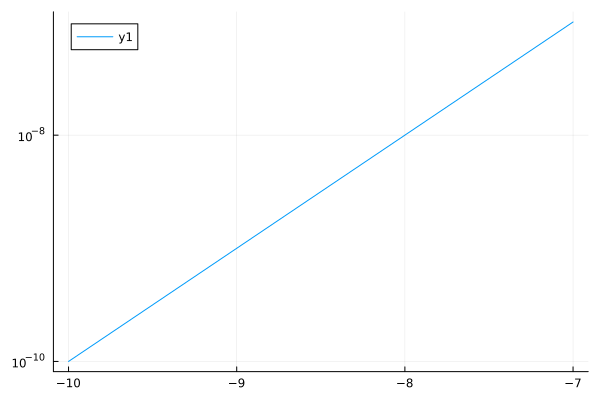

In [3]:
semilogy((-10:1:-7), 10.0 .^ (-10:1:-7))

In [4]:
function myplotheatmap!(plt, f::Function, xlim::Tuple, ylim::Tuple; xlim_box=nothing, ylim_box=nothing)
    x = LinRange(xlim..., 400)
    y = LinRange(ylim..., 400)
    s = heatmap!(plt, y, x, f.(x, y'))

    if !isnothing(xlim_box) && !isnothing(ylim_box)
        plot!(
            plt,
            [ylim_box[1], ylim_box[1], ylim_box[2], ylim_box[2], ylim_box[1]],
            [xlim_box[1], xlim_box[2], xlim_box[2], xlim_box[1], xlim_box[1]],
            color="lightgreen", lw=2, label="",
        )
    end
    xlabel!(L"$x$")
    ylabel!(L"$y$")
    plt
end

function myplotheatmap(func, xlim::Tuple, ylim::Tuple; xlim_box=nothing, ylim_box=nothing)
    plt = plot(xlim=ylim, ylim=xlim, aspect_ratio=:equal, xlabel=L"$x$", ylabel=L"$y$")
    myplotheatmap!(plt, func, xlim, ylim; xlim_box, ylim_box)
end

myplotheatmap (generic function with 1 method)

size(f.(x, y')) = (3, 20)


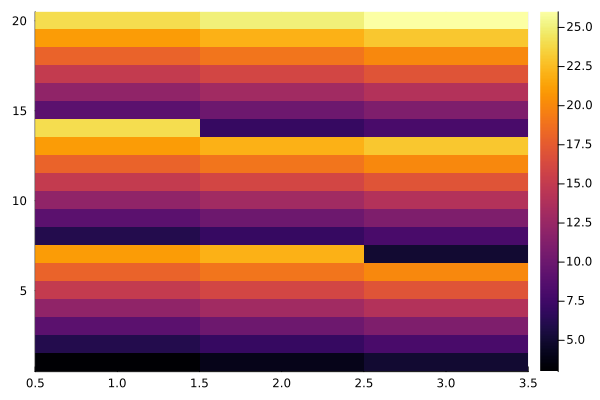

In [5]:
using Plots

x = 1:3
y = 1:20

f(x, y) = 2x + y
@show size(f.(x, y'))
heatmap(x, y, f.(x, y'))